### DATA CLEANING AND CONSOLIDATION FOR ECOPLANET BAMBOO
### OUTCOME: ONE TABLE CONTAINING ALL DATA FROM DIFFERENT SOURCES PER CLUMP FOR MODELLING]
### AUTHOR: ELKANA KIPRUTO

#### Consolidation process for different sources of data:
* Ecoplanet Ground Truth Data (June 2025, March 2026, June 2026)
* Acre Insights Drone Derived Data
* Acre Insights Ground Truth Data

#### Step 1: Importing the libraries

In [1]:
import pandas as pd
import geopandas as gpd
# import xml.etree.ElementTree as ET
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, Polygon
import contextily as ctx
import os
import re
# import fiona
import glob
import matplotlib.pyplot as plt
import seaborn as sns

#### Define the standard final columns we are targeting

In [276]:
target_cols = [
    'psp_id',
    'date_of_measurement',
    'geometry',
    'centroid',
    'clump_id',
    'canopy_area',
    'canopy_volume',
    'hmax',
    'hmin',
    'hmean',
    'hmedian',
    'hstd',
    'gap_fraction',
    'gt_hmax',
    'gt_canopy_diam',
    'gt_dbh_max',
    'gt_dbh_mean',
    'gt_dbh_min',
    'gt_no_of_culms',
    'biomass'
]

In [277]:
df_final_template = pd.DataFrame(columns=target_cols)

In [278]:
print(f'Target template schema initialized successfully. Total columns: {len(df_final_template.columns)}')

Target template schema initialized successfully. Total columns: 20


#### Reading in the paths and ground truth datasets

In [279]:
june_25_path = '../01_RAW/7PSPs_data_June25.xlsx'
march_26_path = '../01_RAW/7PSPs_data_March26.xlsx'
acre_psp_01_path = '../02_INTERMEDIATE/PSP-1A-APM-01/individual_bamboo_params.gpkg'
acre_psp_07_path = '../02_INTERMEDIATE/PSP-1A-APM-07/individual_bamboo_params.gpkg'
acre_psp_08_path = '../02_INTERMEDIATE/PSP-1A-APM-08/individual_bamboo_params.gpkg'

#ground truth validation kml
acre_ground_validation_path = '../01_RAW/height_validation_acre.kml'

In [280]:
#initial done 3 psps
df_apm1_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-APM-1')
df_apm1_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-APM-1')
df_apm7_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-APM-7')
df_apm7_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-APM-7')
df_apm8_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-APM-8')
df_apm8_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-APM-8')

#the other 4 psps
df_apm2_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-APM-2')
df_apm2_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-APM-2')
df_apm13_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-APM-13')
df_apm13_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-APM-13')
df_gb3_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-GB-3')
df_gb3_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-GB-3')
df_gb5_june25 = pd.read_excel(june_25_path, sheet_name='PSP 1a-GB-5')
df_gb5_march26 = pd.read_excel(march_26_path, sheet_name='PSP 1a-GB-5')

#### Cleaning the ground truth data

In [281]:
df_apm1_june25.head()

,Biomass Monitoring,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73
0,PSP,1a-APM-01,NaN,NaN,NaN,Center Point GPS,"-2.008053, 29.683767",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CLUMP #1,NaN,NaN,NaN,NaN,CLUMP #2,NaN,NaN,NaN,NaN,...,NaN,CLUMP #14,NaN,NaN,NaN,NaN,CLUMP #15,NaN,NaN,NaN
3,GPS Coordinate,"-2.007822, 29.683745",NaN,NaN,NaN,GPS Coordinate,"-2.007838, 29.683792",NaN,NaN,NaN,...,NaN,GPS Coordinate,"-2.008365, 29.683648",NaN,NaN,NaN,GPS Coordinate,"-2.008408, 29.68361",NaN,NaN
4,Culm Number (#),Culm Diameter (cm),Culm Diameter (mm),AGB_CULM \n(Kg),NaN,Culm Number (#),Culm Diameter (cm),Culm Diameter (mm),AGB_CULM \n(Kg),NaN,...,NaN,Culm Number (#),Culm Diameter (cm),Culm Diameter (mm),AGB_CULM \n(Kg),NaN,Culm Number (#),Culm Diameter (cm),Culm Diameter (mm),AGB_CULM \n(Kg)


In [282]:
df_apm1_march26.head()

,Biomass Monitoring,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58
0,PSP,1a-APM-1,NaN,NaN,Center Point GPS,"-2.00804333, 29.683715",NaN,NaN,DATE,2026-04-02 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CLUMP #1,NaN,NaN,NaN,CLUMP #2,NaN,NaN,NaN,CLUMP #3,NaN,...,NaN,NaN,NaN,CLUMP #14,NaN,NaN,NaN,CLUMP #15,NaN,NaN
3,GPS Coordinate,"-2.00774333, 29.68373",NaN,NaN,GPS Coordinate,"-2.00776833, 29.68378333",NaN,NaN,GPS Coordinate,"-2.00783333, 29.683785",...,"-2.00827167, 29.68365167",NaN,NaN,GPS Coordinate,"-2.00832667, 29.68363",NaN,NaN,GPS Coordinate,"-2.00836167, 29.68357333",NaN
4,Culm Number (#),Culm Diameter (cm),AGB_CULM \n(Kg),NaN,Culm Number (#),Culm Diameter (cm),AGB_CULM \n(Kg),NaN,Culm Number (#),Culm Diameter (cm),...,Culm Diameter (cm),AGB_CULM \n(Kg),NaN,Culm Number (#),Culm Diameter (cm),AGB_CULM \n(Kg),NaN,Culm Number (#),Culm Diameter (cm),AGB_CULM \n(Kg)


In [283]:
to_be_cleaned = [df_apm1_june25, df_apm1_march26, df_apm7_june25, df_apm7_march26, df_apm8_june25, df_apm8_march26, df_apm2_june25, df_apm2_march26,
                 df_apm13_june25, df_apm13_march26, df_gb3_june25, df_gb3_march26, df_gb5_june25, df_gb5_march26
                 ]

#### Function to parse all the data from the excel workbook to pandas dataframe

In [284]:
def clean_biomass_df(df):
    """
    Cleans and structures biomass data from the provided excel sheet layout.
    Preserves clumps with no records by creating a single row placeholder 
    noting "No records found" instead of skipping them.
    """
    plot_id = None
    date_val = None
    
    # 1. Target exact cell coordinates for global Plot Metadata
    for r in range(min(3, df.shape[0])):
        row_values = [str(x).strip() for x in df.iloc[r].tolist()]
        for idx, val in enumerate(row_values):
            if '1a-' in val.lower() or 'apm' in val.lower():
                plot_id = val
            if 'DATE' in val.upper() and idx + 1 < len(row_values):
                date_val = row_values[idx + 1]

    # 2. Dynamically find all Clump start columns from Row index 2
    clump_indices = []
    if df.shape[0] > 2:
        row_2 = df.iloc[2].tolist()
        for idx, val in enumerate(row_2):
            if pd.notna(val) and 'CLUMP' in str(val).upper():
                clump_indices.append(idx)
                
    all_clumps = []
    num_cols = df.shape[1]
    
    # 3. Process each clump based on dynamic boundaries
    for i, start_col in enumerate(clump_indices):
        end_col = clump_indices[i + 1] if i + 1 < len(clump_indices) else num_cols
        
        # Slice the chunk for this specific clump
        clump_chunk = df.iloc[:, start_col:end_col]
        
        # Extract Clump ID
        clump_id = str(df.iloc[2, start_col]).strip()
        
        if df.shape[0] <= 5:
            continue
            
        # Extract data rows from row index 5 downward
        data_rows = clump_chunk.iloc[5:].copy()
        
        # Dynamic Column Naming using robust case-insensitive substring checks
        headers = [str(h).strip().upper() for h in clump_chunk.iloc[4].tolist()]
        col_names = []
        for idx, h in enumerate(headers):
            if 'NUMBER' in h:
                col_names.append('Culm_Number')
            elif 'DIAMETER (CM)' in h or 'DIAMETER_CM' in h:
                col_names.append('Culm_Diameter_cm')
            elif 'DIAMETER (MM)' in h or 'DIAMETER_MM' in h:
                col_names.append('Culm_Diameter_mm')
            elif 'AGB_CULM' in h or '(KG)' in h:
                col_names.append('AGB_Culm')
            else:
                col_names.append(f'Spacer_Col_{idx}')
                
        data_rows.columns = col_names
        
        # 4. Clean data rows and drop footer/totals
        # First, drop completely empty records in Culm_Number
        data_rows = data_rows.dropna(subset=['Culm_Number'])
        
        # Safe string evaluation to eliminate rows matching summary labels like 'AGB CLUMP'
        def is_summary_row(row):
            for val in row.values:
                if pd.notna(val) and 'AGB CLUMP' in str(val).upper():
                    return True
            return False
            
        summary_mask = data_rows.apply(is_summary_row, axis=1)
        data_rows = data_rows[~summary_mask]
        
        # Filter down to valid numeric indices to separate spacer values from numeric logs
        data_rows['Culm_Number_Numeric'] = pd.to_numeric(data_rows['Culm_Number'], errors='coerce')
        data_rows = data_rows.dropna(subset=['Culm_Number_Numeric']).drop(columns=['Culm_Number_Numeric'])
        
        # --- NEW LOGIC: Handle empty clumps gracefully ---
        if data_rows.empty:
            # Create a fallback single row dictionary filled with your preservation note
            fallback_row = {
                'Culm_Number': 'No records found',
                'Culm_Diameter_cm': 'No records found',
                'AGB_Culm': 'No records found'
            }
            # Fallback for mm tracking columns if present in sheet structures
            if 'Culm_Diameter_mm' in col_names:
                fallback_row['Culm_Diameter_mm'] = 'No records found'
                
            data_rows = pd.DataFrame([fallback_row])
        else:
            # Remove unwanted spacer columns dynamically if the data rows exist
            data_rows = data_rows.loc[:, ~data_rows.columns.str.startswith('Spacer_Col_')]
        
        # Inject metadata
        data_rows['Plot_ID'] = plot_id
        data_rows['Date'] = date_val
        data_rows['Clump_ID'] = clump_id
        
        all_clumps.append(data_rows)
        
    # 5. Concatenate all data chunks safely
    cols_order = ['Plot_ID', 'Date', 'Clump_ID', 'Culm_Number', 'Culm_Diameter_cm', 'AGB_Culm']
    
    if not all_clumps:
        return pd.DataFrame(columns=cols_order)
        
    cleaned_df = pd.concat(all_clumps, ignore_index=True)
    
    # Ensure all columns exist in final output schema even if empty
    for c in cols_order:
        if c not in cleaned_df.columns:
            cleaned_df[c] = None
            
    return cleaned_df[cols_order]


In [ ]:
master_list = []

for raw_df in to_be_cleaned:
    # Clean each already-loaded df using the function
    cleaned_data = clean_biomass_df(raw_df)
    
    # FIX 1: Only append if the dataframeA actually contains extracted rows
    if not cleaned_data.empty:
        master_list.append(cleaned_data)

# FIX 2: Prevent pd.concat crash if no valid data was found across all sheets
if master_list:
    final_dataset = pd.concat(master_list, ignore_index=True)
    
    # FIX 3: Safe datetime conversion with errors='coerce' to bypass messy strings
    final_dataset['Date'] = pd.to_datetime(final_dataset["Date"], errors='coerce', format="mixed")
    
    # Extract only the date component safely, ignoring nulls
    final_dataset['Year'] = final_dataset['Date'].dt.year
    final_dataset['Date'] = final_dataset["Date"].dt.date
else:
    # Fallback to an empty dataframe with correct schema if no data matched
    cols_order = ['Plot_ID', 'Date', 'Clump_ID', 'Culm_Number', 'Culm_Diameter_cm', 'AGB_Culm']
    final_dataset = pd.DataFrame(columns=cols_order)

In [286]:
len(final_dataset)

6992

In [287]:
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6992 entries, 0 to 6991
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Plot_ID           6992 non-null   str   
 1   Date              6992 non-null   object
 2   Clump_ID          6992 non-null   str   
 3   Culm_Number       6992 non-null   object
 4   Culm_Diameter_cm  6992 non-null   object
 5   AGB_Culm          6992 non-null   object
 6   Year              6992 non-null   int32 
dtypes: int32(1), object(4), str(2)
memory usage: 355.2+ KB


In [288]:
final_dataset[final_dataset['Culm_Number'] == 'No records found']

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
1062,1a-APM-7,2026-02-20,CLUMP #2,No records found,No records found,No records found,2026
4085,1a-APM-13,2026-03-17,CLUMP #1,No records found,No records found,No records found,2026
4086,1a-APM-13,2026-03-17,CLUMP #2,No records found,No records found,No records found,2026
4087,1a-APM-13,2026-03-17,CLUMP #3,No records found,No records found,No records found,2026
4088,1a-APM-13,2026-03-17,CLUMP #4,No records found,No records found,No records found,2026
4089,1a-APM-13,2026-03-17,CLUMP #5,No records found,No records found,No records found,2026
4090,1a-APM-13,2026-03-17,CLUMP #6,No records found,No records found,No records found,2026
4091,1a-APM-13,2026-03-17,CLUMP #7,No records found,No records found,No records found,2026
4092,1a-APM-13,2026-03-17,CLUMP #8,No records found,No records found,No records found,2026
4174,1a-APM-13,2026-03-17,CLUMP #12,No records found,No records found,No records found,2026


In [289]:
# Columns to update
cols = ["Culm_Number", "Culm_Diameter_cm", "AGB_Culm"]

# Replace the text with 0 and convert columns to numeric types
for col in cols:
    final_dataset[col] = final_dataset[col].replace("No records found", 0)

# Cast Culm_Number to integer, others to float
final_dataset["Culm_Number"] = final_dataset["Culm_Number"].astype(int)
final_dataset["Culm_Diameter_cm"] = final_dataset["Culm_Diameter_cm"].astype(float)
final_dataset["AGB_Culm"] = final_dataset["AGB_Culm"].astype(float)

In [290]:
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6992 entries, 0 to 6991
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Plot_ID           6992 non-null   str    
 1   Date              6992 non-null   object 
 2   Clump_ID          6992 non-null   str    
 3   Culm_Number       6992 non-null   int64  
 4   Culm_Diameter_cm  6992 non-null   float64
 5   AGB_Culm          6992 non-null   float64
 6   Year              6992 non-null   int32  
dtypes: float64(2), int32(1), int64(1), object(1), str(2)
memory usage: 355.2+ KB


In [291]:
df_2026 = final_dataset[final_dataset['Year'] == 2026].copy()
df_2025 = final_dataset[final_dataset['Year'] == 2025].copy()

<Axes: xlabel='Culm_Number', ylabel='Count'>

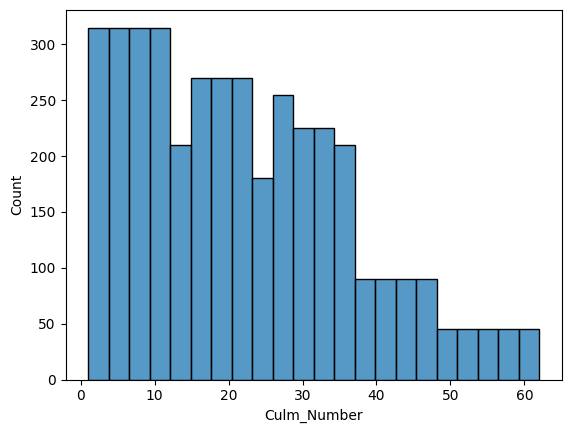

In [292]:
sns.histplot(df_2025['Culm_Number'])

<Axes: xlabel='Culm_Number', ylabel='Count'>

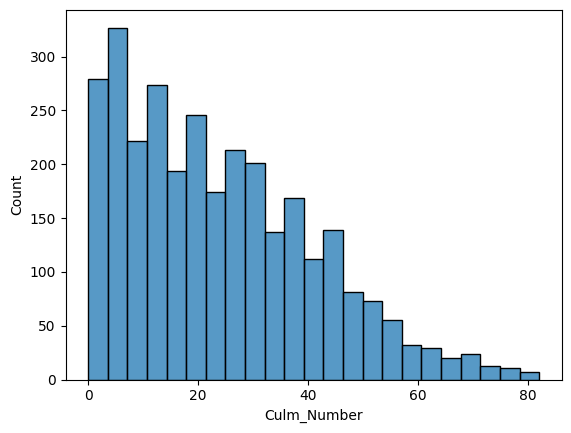

In [293]:
sns.histplot(df_2026['Culm_Number'])

In [294]:
df_2026.describe()

,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
count,3032.000000,3032.000000,3032.000000,3032.0
mean,24.028034,1.998368,3.705563,2026.0
std,17.291861,0.876168,2.771129,0.0
min,0.000000,0.000000,0.000000,2026.0
25%,10.000000,1.401250,1.715085,2026.0
50%,21.000000,1.996000,3.244908,2026.0
75%,36.000000,2.566500,5.104824,2026.0
max,82.000000,9.043000,49.407955,2026.0


In [295]:
df_2025.describe()

,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
count,3960.000000,3960.000000,3960.000000,3960.0
mean,22.003788,0.607104,1.002735,2025.0
std,14.588183,0.941534,1.884333,0.0
min,1.000000,0.000000,0.000000,2025.0
25%,10.000000,0.000000,0.000000,2025.0
50%,20.000000,0.000000,0.000000,2025.0
75%,32.000000,1.232750,1.361456,2025.0
max,62.000000,4.224000,12.530577,2025.0


##### Clean the 2025 dataframe

In [296]:
def clean_bamboo_2025_zeros(df):
    # 1. Subset the records for the year 2025
    df_2025 = df[df['Year'] == 2025].copy()
    
    # 2. Separate rows with real culms (> 0 diameter) from zero entries
    valid_culms = df_2025[df_2025['Culm_Diameter_cm'] > 0].copy()
    zero_culms = df_2025[df_2025['Culm_Diameter_cm'] == 0].copy()
    
    # 3. Handle clumps where every single record is 0
    # Find unique Plot+Clump combinations that have at least one valid culm
    valid_clump_keys = valid_culms[['Plot_ID', 'Clump_ID']].drop_duplicates()
    
    # Left join zero records with valid keys to flag clumps that have valid culms
    merged = zero_culms.merge(valid_clump_keys, on=['Plot_ID', 'Clump_ID'], how='left', indicator=True)
    
    # Filter for rows where the Plot+Clump combination has NO valid culms at all
    all_zero_clumps = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
    
    # Drop duplicates to keep exactly one record per all-zero clump
    preserved_clumps = all_zero_clumps.drop_duplicates(subset=['Plot_ID', 'Clump_ID']).copy()
    
    # Force the Culm_Number to 0 for these completely empty clumps
    preserved_clumps['Culm_Number'] = 0
    
    # 4. Recombine valid culms and preserved empty clumps
    cleaned_df = pd.concat([valid_culms, preserved_clumps]).sort_index()
    
    # 5. Recalculate and update the Culm_Number to reflect the true non-zero count
    # Count how many valid culms exist per unique Plot + Clump combination
    true_counts = valid_culms.groupby(['Plot_ID', 'Clump_ID']).size().reset_index(name='True_Count')
    
    # Map the true counts back to the cleaned dataframe
    cleaned_df = cleaned_df.merge(true_counts, on=['Plot_ID', 'Clump_ID'], how='left')
    cleaned_df['Culm_Number'] = cleaned_df['True_Count'].fillna(0).astype(int)
    cleaned_df = cleaned_df.drop(columns=['True_Count'])
    
    return cleaned_df


In [297]:
df_2025_no_zeros = clean_bamboo_2025_zeros(final_dataset)

In [298]:
df_2025_no_zeros.describe()

,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
count,1447.000000,1447.000000,1447.000000,1447.0
mean,28.344160,1.661460,2.744182,2025.0
std,14.693141,0.821053,2.222461,0.0
min,0.000000,0.000000,0.000000,2025.0
25%,17.000000,1.063000,1.042411,2025.0
50%,27.000000,1.614000,2.212717,2025.0
75%,38.000000,2.214000,3.911447,2025.0
max,62.000000,4.224000,12.530577,2025.0


In [299]:
df_2026.describe()

,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
count,3032.000000,3032.000000,3032.000000,3032.0
mean,24.028034,1.998368,3.705563,2026.0
std,17.291861,0.876168,2.771129,0.0
min,0.000000,0.000000,0.000000,2026.0
25%,10.000000,1.401250,1.715085,2026.0
50%,21.000000,1.996000,3.244908,2026.0
75%,36.000000,2.566500,5.104824,2026.0
max,82.000000,9.043000,49.407955,2026.0


In [300]:
final_dataset = pd.concat([df_2026, df_2025_no_zeros], ignore_index=True)

In [301]:
len(final_dataset)

4479

In [302]:
final_dataset.head()

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
0,1a-APM-1,2026-04-02,CLUMP #1,1,2.457,4.719020,2026
1,1a-APM-1,2026-04-02,CLUMP #1,2,3.220,7.683080,2026
2,1a-APM-1,2026-04-02,CLUMP #1,3,2.460,4.729410,2026
3,1a-APM-1,2026-04-02,CLUMP #1,4,1.165,1.229583,2026
4,1a-APM-1,2026-04-02,CLUMP #1,5,2.228,3.956138,2026


In [303]:
final_dataset[final_dataset['Culm_Diameter_cm'].isna()]

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year


In [304]:
final_dataset.sample(10)

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
3428,1a-APM-08,2025-05-15,CLUMP #6,36,1.101,1.110533,2025
4195,1a-GB-05,2025-06-18,CLUMP #7,5,1.721,2.484104,2025
1487,1a-APM-2,2026-05-03,CLUMP #6,9,1.518,1.981194,2026
2101,1a-GB-03,2026-06-03,CLUMP #5,52,1.493,1.922776,2026
891,1a-APM-8,2026-02-24,CLUMP #1,10,0.413,0.189687,2026
553,1a-APM-7,2026-02-20,CLUMP #9,14,1.785,2.653076,2026
3614,1a-APM-02,2025-04-25,CLUMP #11,18,1.326,1.552673,2025
3342,1a-APM-08,2025-05-15,CLUMP #3,38,2.929,6.477305,2025
662,1a-APM-7,2026-02-20,CLUMP #11,65,0.679,0.464722,2026
361,1a-APM-7,2026-02-20,CLUMP #4,42,0.968,0.880563,2026


In [305]:
final_dataset['Date'].unique()

array([datetime.date(2026, 4, 2), datetime.date(2026, 2, 20),
       datetime.date(2026, 2, 24), datetime.date(2026, 5, 3),
       datetime.date(2026, 3, 17), datetime.date(2026, 6, 3),
       datetime.date(2026, 3, 13), datetime.date(2025, 4, 24),
       datetime.date(2025, 5, 15), datetime.date(2025, 4, 25),
       datetime.date(2025, 6, 18), datetime.date(2025, 5, 20)],
      dtype=object)

In [306]:
final_dataset.columns = final_dataset.columns.str.lower()

In [307]:
final_dataset.head()

,plot_id,date,clump_id,culm_number,culm_diameter_cm,agb_culm,year
0,1a-APM-1,2026-04-02,CLUMP #1,1,2.457,4.719020,2026
1,1a-APM-1,2026-04-02,CLUMP #1,2,3.220,7.683080,2026
2,1a-APM-1,2026-04-02,CLUMP #1,3,2.460,4.729410,2026
3,1a-APM-1,2026-04-02,CLUMP #1,4,1.165,1.229583,2026
4,1a-APM-1,2026-04-02,CLUMP #1,5,2.228,3.956138,2026


In [308]:
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 4479 entries, 0 to 4478
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   plot_id           4479 non-null   str    
 1   date              4479 non-null   object 
 2   clump_id          4479 non-null   str    
 3   culm_number       4479 non-null   int64  
 4   culm_diameter_cm  4479 non-null   float64
 5   agb_culm          4479 non-null   float64
 6   year              4479 non-null   int32  
dtypes: float64(2), int32(1), int64(1), object(1), str(2)
memory usage: 227.6+ KB


<Axes: >

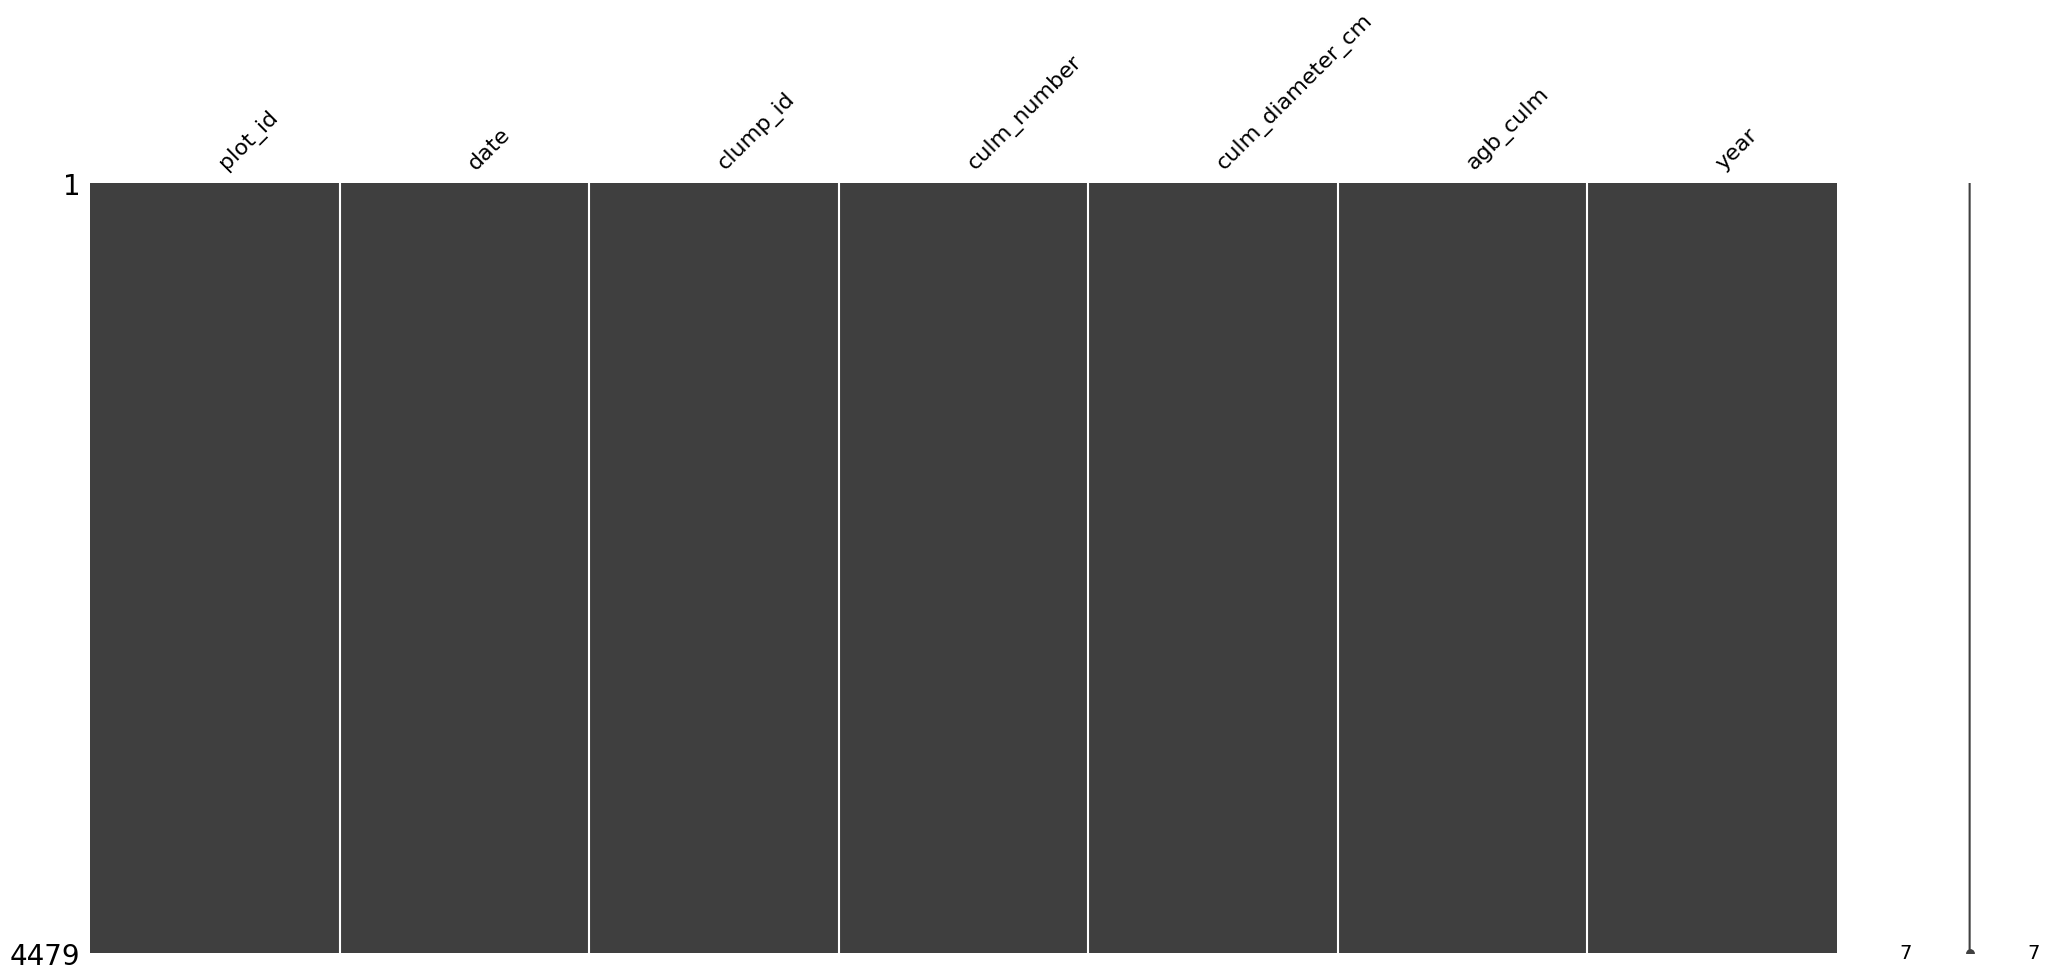

In [309]:
msno.matrix(final_dataset)

In [310]:
final_dataset['plot_id'].unique()

<StringArray>
[ '1a-APM-1',  '1a-APM-7',  '1a-APM-8',  '1a-APM-2', '1a-APM-13',  '1a-GB-03',
  '1a-GB-05', '1a-APM-01', '1a-APM-07', '1a-APM-08', '1a-APM-02']
Length: 11, dtype: str

In [311]:
# Strip whitespace and pad the final number with a leading zero if it is a single digit
final_dataset['plot_id'] = final_dataset['plot_id'].astype(str).str.replace(
    r'-(\d+)$', 
    lambda x: f"-{int(x.group(1)):02d}", 
    regex=True
)

In [312]:
final_dataset['plot_id'].unique()

<StringArray>
['1a-APM-01', '1a-APM-07', '1a-APM-08', '1a-APM-02', '1a-APM-13',  '1a-GB-03',
  '1a-GB-05']
Length: 7, dtype: str

In [313]:
len(final_dataset)

4479

In [314]:
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 4479 entries, 0 to 4478
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   plot_id           4479 non-null   str    
 1   date              4479 non-null   object 
 2   clump_id          4479 non-null   str    
 3   culm_number       4479 non-null   int64  
 4   culm_diameter_cm  4479 non-null   float64
 5   agb_culm          4479 non-null   float64
 6   year              4479 non-null   int32  
dtypes: float64(2), int32(1), int64(1), object(1), str(2)
memory usage: 227.6+ KB


In [315]:
final_dataset.to_csv("../02_INTERMEDIATE/7psps_with_biomass_ecoplanet.csv", index=False)

In [316]:
df_gt_ecoplanet = pd.read_csv("../02_INTERMEDIATE/7psps_with_biomass_ecoplanet.csv")

In [317]:
df_gt_ecoplanet.head()

,plot_id,date,clump_id,culm_number,culm_diameter_cm,agb_culm,year
0,1a-APM-01,2026-04-02,CLUMP #1,1,2.457,4.719020,2026
1,1a-APM-01,2026-04-02,CLUMP #1,2,3.220,7.683080,2026
2,1a-APM-01,2026-04-02,CLUMP #1,3,2.460,4.729410,2026
3,1a-APM-01,2026-04-02,CLUMP #1,4,1.165,1.229583,2026
4,1a-APM-01,2026-04-02,CLUMP #1,5,2.228,3.956138,2026


#### Review completeness

In [318]:
# 1. Get all unique plots and years actually present in your data
unique_plots = df_gt_ecoplanet['plot_id'].unique()
unique_years = df_gt_ecoplanet['year'].unique()

# 2. Generate the 15 expected clump IDs
expected_clumps = [f"CLUMP #{i}" for i in range(1, 16)]

# 3. Build a perfect reference grid of all required combinations
expected_grid = pd.MultiIndex.from_product(
    [unique_plots, unique_years, expected_clumps],
    names=['plot_id', 'year', 'clump_id']
)

In [319]:
# 4. Convert your current data's columns into a MultiIndex
actual_grid = pd.MultiIndex.from_frame(df_gt_ecoplanet[['plot_id', 'year', 'clump_id']])

# 5. Find the combinations that exist in the expected grid but not in your data
missing_combinations = expected_grid.difference(actual_grid)

# 6. Convert the result into a readable DataFrame
missing_df = missing_combinations.to_frame(index=False)

In [320]:
missing_df

,plot_id,year,clump_id


##### All PSPs are complete for all years: have 15 clumps recorded for each psp, each year

In [321]:
df_gt_ecoplanet.info()

<class 'pandas.DataFrame'>
RangeIndex: 4479 entries, 0 to 4478
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   plot_id           4479 non-null   str    
 1   date              4479 non-null   str    
 2   clump_id          4479 non-null   str    
 3   culm_number       4479 non-null   int64  
 4   culm_diameter_cm  4479 non-null   float64
 5   agb_culm          4479 non-null   float64
 6   year              4479 non-null   int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 245.1 KB


In [322]:
df_gt_ecoplanet['culm_diameter_cm'] = df_gt_ecoplanet['culm_diameter_cm'].round(2)
df_gt_ecoplanet['agb_culm'] = df_gt_ecoplanet['agb_culm'].round(2)

#### Aggregate biomass values

In [323]:
df_clean = df_gt_ecoplanet.copy()

# --- STEP 1.5: Temporarily turn 0s to NaN for biomass calculations ---
# This ensures 0s don't skew min, mean, or median downward.
df_clean["agb_culm_nan"] = df_clean["agb_culm"].replace(0, np.nan)

# --- STEP 2: Aggregate the Data ---
aggregated_df_7psps = (
    df_clean.groupby(["plot_id", "year", "clump_id"])
    .agg(
        # Calculate stats using the column where 0s are NaN (they will be ignored)
        max_culm_agb=("agb_culm_nan", "max"),
        avg_culm_agb=("agb_culm_nan", "mean"),
        min_culm_agb=("agb_culm_nan", "min"),
        median_culm_agb=("agb_culm_nan", "median"),
        total_agb=("agb_culm_nan", "sum"),
        # Culm count still looks at the original column to capture everything
        total_culms=("culm_number", "max"),
    )
    .reset_index()
)

# --- STEP 3: Handle completely empty clumps ---
# If a clump only had 0s, its stats are NaN. Turn them back to 0.0.
cols_to_zero = [
    "max_culm_agb",
    "avg_culm_agb",
    "min_culm_agb",
    "median_culm_agb",
    "total_agb"
]
aggregated_df_7psps[cols_to_zero] = aggregated_df_7psps[cols_to_zero].fillna(
    0.0
)

In [324]:
aggregated_df_7psps.head()

,plot_id,year,clump_id,max_culm_agb,avg_culm_agb,min_culm_agb,median_culm_agb,total_agb,total_culms
0,1a-APM-01,2025,CLUMP #1,5.89,3.150000,0.15,2.840,34.65,11
1,1a-APM-01,2025,CLUMP #10,5.66,2.603333,0.39,2.230,23.43,9
2,1a-APM-01,2025,CLUMP #11,3.56,1.748333,0.08,1.680,10.49,6
3,1a-APM-01,2025,CLUMP #12,1.40,0.641111,0.10,0.560,5.77,9
4,1a-APM-01,2025,CLUMP #13,1.80,1.028333,0.10,1.135,6.17,6


In [325]:
len(aggregated_df_7psps)

210

#### Merge with initially corrected geometries dataset

In [326]:
corrected_geom_ecoplanet_path = '../02_INTERMEDIATE/ecoplanet_final_dataset_V01.gpkg'
gdf_corrected = gpd.read_file(corrected_geom_ecoplanet_path)

In [327]:
gdf_corrected.head()

,plot_id,year,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,median_culm_agb,lat,lon,geometry
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,3.15,0.15,2.84,-2.01,29.68,POINT (798561.167 9777829.31)
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,1.18,0.17,0.82,-2.01,29.68,POINT (798566.397 9777827.531)
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.01,29.68,POINT (798568.951 9777823.765)
3,1a-APM-01,2025,CLUMP #4,1,0.78,0.91,0.91,0.91,0.91,0.78,0.78,0.78,0.78,-2.01,29.68,POINT (798569.834 9777819.337)
4,1a-APM-01,2025,CLUMP #5,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.01,29.68,POINT (798568.154 9777812.922)


In [328]:
len(gdf_corrected)

210

In [329]:
# 1. Select only the necessary columns from the second (spatial) dataframe
df_spatial_selected = gdf_corrected[
    [
        "plot_id",
        "year",
        "clump_id",
        "max_culm_diameter_cm",
        "avg_culm_diameter_cm",
        "min_culm_diameter_cm",
        "median_culm_diameter_cm",
        "lat",
        "lon",
        "geometry",
    ]
]

# 2. Merge them together using an inner join on the 3 unique keys
merged_df = pd.merge(
    df_spatial_selected,
    aggregated_df_7psps,  # Your first df with AGB stats and total_culms
    on=["plot_id", "year", "clump_id"],
    how="inner",
)

# 3. Ensure Python recognizes it as a GeoDataFrame so you don't lose map functionality
merged_gpd = gpd.GeoDataFrame(merged_df, geometry="geometry", crs='EPSG:32735')


In [330]:
len(merged_gpd)

210

In [331]:
merged_gpd.head()

,plot_id,year,clump_id,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,lat,lon,geometry,max_culm_agb,avg_culm_agb,min_culm_agb,median_culm_agb,total_agb,total_culms
0,1a-APM-01,2025,CLUMP #1,2.78,1.86,0.36,1.85,-2.01,29.68,POINT (798561.167 9777829.31),5.89,3.150000,0.15,2.840,34.65,11
1,1a-APM-01,2025,CLUMP #2,2.16,1.06,0.39,0.93,-2.01,29.68,POINT (798566.397 9777827.531),3.73,1.176429,0.17,0.815,16.47,14
2,1a-APM-01,2025,CLUMP #3,0.00,0.00,0.00,0.00,-2.01,29.68,POINT (798568.951 9777823.765),0.00,0.000000,0.00,0.000,0.00,0
3,1a-APM-01,2025,CLUMP #4,0.91,0.91,0.91,0.91,-2.01,29.68,POINT (798569.834 9777819.337),0.78,0.780000,0.78,0.780,0.78,1
4,1a-APM-01,2025,CLUMP #5,0.00,0.00,0.00,0.00,-2.01,29.68,POINT (798568.154 9777812.922),0.00,0.000000,0.00,0.000,0.00,0


In [332]:
# 1. Extract the number from 'clump_id' as an integer for proper sorting
merged_gpd["clump_sort_num"] = (
    merged_gpd["clump_id"].str.extract(r"(\d+)").astype(int)
)

# 2. Sort by plot_id, year, and then the numeric clump order
merged_gpd = merged_gpd.sort_values(
    by=["plot_id", "year", "clump_sort_num"]
).reset_index(drop=True)

# 3. Drop the temporary sorting column to keep the dataset clean
merged_gpd = merged_gpd.drop(columns=["clump_sort_num"])

In [333]:
merged_gpd.columns

Index(['plot_id', 'year', 'clump_id', 'max_culm_diameter_cm',
       'avg_culm_diameter_cm', 'min_culm_diameter_cm',
       'median_culm_diameter_cm', 'lat', 'lon', 'geometry', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'total_agb',
       'total_culms'],
      dtype='str')

In [334]:
merged_gpd = merged_gpd[['plot_id', 'year', 'clump_id','total_culms','total_agb', 'max_culm_diameter_cm',
       'avg_culm_diameter_cm', 'min_culm_diameter_cm',
       'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb','lat', 'lon', 'geometry']]

In [335]:
##round all numerics to 2 decimal places
merged_gpd.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   plot_id                  210 non-null    str     
 1   year                     210 non-null    int64   
 2   clump_id                 210 non-null    str     
 3   total_culms              210 non-null    int64   
 4   total_agb                210 non-null    float64 
 5   max_culm_diameter_cm     210 non-null    float64 
 6   avg_culm_diameter_cm     210 non-null    float64 
 7   min_culm_diameter_cm     210 non-null    float64 
 8   median_culm_diameter_cm  210 non-null    float64 
 9   max_culm_agb             210 non-null    float64 
 10  avg_culm_agb             210 non-null    float64 
 11  min_culm_agb             210 non-null    float64 
 12  median_culm_agb          210 non-null    float64 
 13  lat                      210 non-null    float64 
 14  lo

In [336]:
merged_gpd = merged_gpd.astype({'max_culm_diameter_cm' : 'float64', 'avg_culm_diameter_cm' : 'float64', 'min_culm_diameter_cm' : 'float64',
                                'median_culm_diameter_cm' : 'float64'})

In [337]:
merged_gpd.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   plot_id                  210 non-null    str     
 1   year                     210 non-null    int64   
 2   clump_id                 210 non-null    str     
 3   total_culms              210 non-null    int64   
 4   total_agb                210 non-null    float64 
 5   max_culm_diameter_cm     210 non-null    float64 
 6   avg_culm_diameter_cm     210 non-null    float64 
 7   min_culm_diameter_cm     210 non-null    float64 
 8   median_culm_diameter_cm  210 non-null    float64 
 9   max_culm_agb             210 non-null    float64 
 10  avg_culm_agb             210 non-null    float64 
 11  min_culm_agb             210 non-null    float64 
 12  median_culm_agb          210 non-null    float64 
 13  lat                      210 non-null    float64 
 14  lo

In [338]:
merged_gpd.head()

,plot_id,year,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,median_culm_agb,lat,lon,geometry
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,3.150000,0.15,2.840,-2.01,29.68,POINT (798561.167 9777829.31)
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,1.176429,0.17,0.815,-2.01,29.68,POINT (798566.397 9777827.531)
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,0.000000,0.00,0.000,-2.01,29.68,POINT (798568.951 9777823.765)
3,1a-APM-01,2025,CLUMP #4,1,0.78,0.91,0.91,0.91,0.91,0.78,0.780000,0.78,0.780,-2.01,29.68,POINT (798569.834 9777819.337)
4,1a-APM-01,2025,CLUMP #5,0,0.00,0.00,0.00,0.00,0.00,0.00,0.000000,0.00,0.000,-2.01,29.68,POINT (798568.154 9777812.922)


In [339]:
#find float columns and round them to 2 decimal places
float_cols = merged_gpd.select_dtypes(include=['float']).columns

# 2. Round those columns and assign them back
merged_gpd[float_cols] = merged_gpd[float_cols].round(2)

In [340]:
merged_gpd.head()

,plot_id,year,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,median_culm_agb,lat,lon,geometry
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,3.15,0.15,2.84,-2.01,29.68,POINT (798561.167 9777829.31)
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,1.18,0.17,0.82,-2.01,29.68,POINT (798566.397 9777827.531)
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.01,29.68,POINT (798568.951 9777823.765)
3,1a-APM-01,2025,CLUMP #4,1,0.78,0.91,0.91,0.91,0.91,0.78,0.78,0.78,0.78,-2.01,29.68,POINT (798569.834 9777819.337)
4,1a-APM-01,2025,CLUMP #5,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.01,29.68,POINT (798568.154 9777812.922)


In [341]:
merged_gpd.to_file(f'../02_INTERMEDIATE/ecoplanet_final_dataset_V01.gpkg', index=False)
merged_gpd.to_csv(f'../02_INTERMEDIATE/ecoplanet_final_dataset_V01.csv', index=False)

In [342]:
# # 1. Split the coordinate string into two separate columns
# df_gt_ecoplanet[["lat", "lon"]] = df_gt_ecoplanet["clump_gps"].str.split(",", expand=True)

# # 2. Convert coordinates to float numbers
# df_gt_ecoplanet["lat"] = df_gt_ecoplanet["lat"].astype(float)
# df_gt_ecoplanet["lon"] = df_gt_ecoplanet["lon"].astype(float)

# # 3. Create the GeoDataFrame (using EPSG:4326 for standard GPS WGS84)
# gdf_gt_ecoplanet = gpd.GeoDataFrame(
#     df_gt_ecoplanet,
#     geometry=gpd.points_from_xy(df_gt_ecoplanet["lon"], df_gt_ecoplanet["lat"]),
#     crs="EPSG:4326",
# )

# gdf_gt_ecoplanet_26 = gdf_gt_ecoplanet[gdf_gt_ecoplanet['year'] == 2026]
# gdf_gt_ecoplanet_25 = gdf_gt_ecoplanet[gdf_gt_ecoplanet['year'] == 2025]
# gdf_gt_ecoplanet.to_file(f'../02_INTERMEDIATE/psp_biomass_ecoplanet.gpkg', index=False)

In [343]:
gdf_gt_ecoplanet.head(15)

NameError: name 'gdf_gt_ecoplanet' is not defined

In [ ]:
gdf_gt_ecoplanet.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6984 entries, 0 to 6983
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   plot_id           6984 non-null   str     
 1   date              6984 non-null   str     
 2   clump_id          6984 non-null   str     
 3   clump_gps         6984 non-null   str     
 4   culm_number       6984 non-null   int64   
 5   culm_diameter_cm  6984 non-null   float64 
 6   year              6984 non-null   int64   
 7   lat               6984 non-null   float64 
 8   lon               6984 non-null   float64 
 9   geometry          6984 non-null   geometry
dtypes: float64(3), geometry(1), int64(2), str(4)
memory usage: 545.8 KB


In [ ]:
gdf_gt_ecoplanet['clump_id'].unique()

<StringArray>
[ 'CLUMP #1',  'CLUMP #2',  'CLUMP #3',  'CLUMP #4',  'CLUMP #5',  'CLUMP #6',
  'CLUMP #7',  'CLUMP #8',  'CLUMP #9', 'CLUMP #10', 'CLUMP #11', 'CLUMP #12',
 'CLUMP #13', 'CLUMP #14', 'CLUMP #15']
Length: 15, dtype: str

In [ ]:
gdf_clean = gdf_gt_ecoplanet.copy()
gdf_clean['culm_diameter_cm_cleaned'] = gdf_clean['culm_diameter_cm'].replace(0, pd.NA)

# --- STEP 2: Aggregate the Data ---
aggregated_df = gdf_clean.groupby(['plot_id', 'year', 'clump_id']).agg(
    # Diameter stats (ignoring the 0s we turned into NaNs)
    max_culm_diameter_cm=('culm_diameter_cm_cleaned', 'max'),
    avg_culm_diameter_cm=('culm_diameter_cm_cleaned', 'mean'),
    min_culm_diameter_cm=('culm_diameter_cm_cleaned', 'min'),
    median_culm_diameter_cm=('culm_diameter_cm_cleaned', 'median'),
    
    # Culm count (takes max of all rows, including those with 0 diameter)
    total_culms=('culm_number', 'max'),
    
    # Retain spatial information (takes the first instance since it's identical)
    clump_gps=('clump_gps', 'first'),
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    geometry=('geometry', 'first')
).reset_index()

# --- STEP 3: Handle completely empty clumps ---
# If a clump only had 0s (no measurable plants), its min/avg/median/max will be NaN. 
# We should cleanly turn those NaNs back to 0.0.
cols_to_zero = ['max_culm_diameter_cm', 'avg_culm_diameter_cm', 'min_culm_diameter_cm', 'median_culm_diameter_cm']
aggregated_df[cols_to_zero] = aggregated_df[cols_to_zero].fillna(0.0)

In [ ]:
aggregated_df.head()

,plot_id,year,clump_id,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,total_culms,clump_gps,lat,lon,geometry
0,1a-APM-01,2025,CLUMP #1,2.78,1.860909,0.36,1.85,14,"-2.007822, 29.683745",-2.007822,29.683745,POINT (29.68374 -2.00782)
1,1a-APM-01,2025,CLUMP #10,2.72,1.668889,0.62,1.62,14,"-2.008173, 29.683718",-2.008173,29.683718,POINT (29.68372 -2.00817)
2,1a-APM-01,2025,CLUMP #11,2.1,1.286667,0.26,1.355,14,"-2.00822, 29.683697",-2.008220,29.683697,POINT (29.6837 -2.00822)
3,1a-APM-01,2025,CLUMP #12,1.25,0.765556,0.28,0.75,14,"-2.008253, 29.683693",-2.008253,29.683693,POINT (29.68369 -2.00825)
4,1a-APM-01,2025,CLUMP #13,1.44,0.996667,0.3,1.115,14,"-2.008308, 29.683665",-2.008308,29.683665,POINT (29.68366 -2.00831)


#### Is the df complete

In [ ]:
len(aggregated_df)

210

In [ ]:
# 1. Get all unique plots and years actually present in your data
unique_plots = df_gt_ecoplanet['plot_id'].unique()
unique_years = df_gt_ecoplanet['year'].unique()

# 2. Generate the 15 expected clump IDs
expected_clumps = [f"CLUMP #{i}" for i in range(1, 16)]

# 3. Build a perfect reference grid of all required combinations
expected_grid = pd.MultiIndex.from_product(
    [unique_plots, unique_years, expected_clumps],
    names=['plot_id', 'year', 'clump_id']
)

In [ ]:
# 4. Convert your current data's columns into a MultiIndex
actual_grid = pd.MultiIndex.from_frame(aggregated_df[['plot_id', 'year', 'clump_id']])

# 5. Find the combinations that exist in the expected grid but not in your data
missing_combinations = expected_grid.difference(actual_grid)

# 6. Convert the result into a readable DataFrame
missing_df = missing_combinations.to_frame(index=False)

In [ ]:
missing_df

,plot_id,year,clump_id


#### The dataframe is complete

In [ ]:
aggregated_gdf = gpd.GeoDataFrame(aggregated_df, 
    geometry='geometry',
    crs="EPSG:4326")

In [ ]:
aggregated_gdf = aggregated_gdf.to_crs('EPSG:32735')

In [ ]:
aggregated_gdf.to_file('../02_INTERMEDIATE/ecoplanet_final_dataset.gpkg', index=False)
aggregated_gdf.to_csv(f'../02_INTERMEDIATE/ecoplanet_final_dataset.csv', index=False)

#### Acre Insights Dataset

In [ ]:
acre_psp_01 = gpd.read_file(acre_psp_01_path)
acre_psp_07 = gpd.read_file(acre_psp_07_path)
acre_psp_08 = gpd.read_file(acre_psp_08_path)

In [ ]:
acre_psp_01.head()

,hmin,hmax,hmean,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,geometry
0,2.001889,6.514500,4.299261,1.152677,4.601222,114664,164.849042,0.045446,27.440000,"POLYGON ((798559 9777848.8, 798559 9777848.6, ..."
1,2.014333,7.062889,4.931005,1.350432,5.293056,226341,287.124916,0.041733,46.720000,"POLYGON ((798559.8 9777842.8, 798559.8 9777842..."
2,2.000667,6.989333,4.815035,1.288961,4.561666,119588,148.507106,0.114192,25.040000,"POLYGON ((798580.2 9777840, 798580.2 9777838.8..."
3,2.024000,5.973333,4.686057,0.946439,5.057556,213539,148.108231,0.016582,27.474879,"POLYGON ((798567.4 9777832, 798567.134 9777833..."
4,2.007000,5.180666,3.322944,0.847566,3.245556,42938,30.024417,0.035586,7.800000,"POLYGON ((798567.2 9777830.2, 798567.2 9777830..."


In [ ]:
len(acre_psp_08.columns)

10

In [ ]:
acre_psp_01.columns

Index(['hmin', 'hmax', 'hmean', 'hstd', 'hmedian', 'total_points',
       'canopy_volume_m3', 'gap_fraction', 'canopy_area', 'geometry'],
      dtype='str')

In [ ]:
acre_psp_07.columns

Index(['hmin', 'hmax', 'hmean', 'hstd', 'hmedian', 'total_points',
       'canopy_volume_m3', 'gap_fraction', 'canopy_area', 'geometry'],
      dtype='str')

In [ ]:
gdf_acre_drone = pd.concat([acre_psp_01, acre_psp_07, acre_psp_08], join='inner', ignore_index=True)

In [ ]:
gdf_acre_drone['centroid'] = gdf_acre_drone.geometry.centroid

In [ ]:
gdf_acre_drone

,hmin,hmax,hmean,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,geometry,centroid
0,2.001889,6.514500,4.299261,1.152677,4.601222,114664,164.849042,0.045446,27.440000,"POLYGON ((798559 9777848.8, 798559 9777848.6, ...",POINT (798560.85 9777845.286)
1,2.014333,7.062889,4.931005,1.350432,5.293056,226341,287.124916,0.041733,46.720000,"POLYGON ((798559.8 9777842.8, 798559.8 9777842...",POINT (798561.745 9777839.02)
2,2.000667,6.989333,4.815035,1.288961,4.561666,119588,148.507106,0.114192,25.040000,"POLYGON ((798580.2 9777840, 798580.2 9777838.8...",POINT (798582.427 9777837.225)
3,2.024000,5.973333,4.686057,0.946439,5.057556,213539,148.108231,0.016582,27.474879,"POLYGON ((798567.4 9777832, 798567.134 9777833...",POINT (798564.304 9777833.258)
4,2.007000,5.180666,3.322944,0.847566,3.245556,42938,30.024417,0.035586,7.800000,"POLYGON ((798567.2 9777830.2, 798567.2 9777830...",POINT (798566.824 9777828.355)
...,...,...,...,...,...,...,...,...,...,...,...
65,2.000778,2.488111,2.210610,0.130743,2.184889,13581,5.465378,0.289596,2.040000,"POLYGON ((806937 9776569, 806937 9776568.8, 80...",POINT (806937.261 9776567.955)
66,2.000556,3.583000,2.831152,0.423920,2.927111,30010,10.887091,0.247251,3.360000,"POLYGON ((806937.2 9776564.6, 806937.2 9776564...",POINT (806937.807 9776563.552)
67,2.008222,4.122000,3.078767,0.504697,3.152722,73756,32.413492,0.199441,9.040000,"POLYGON ((806932.4 9776557.6, 806932.4 9776557...",POINT (806932.326 9776555.843)
68,2.042222,7.759889,5.468242,1.463673,5.850444,238605,324.853763,0.247065,44.360000,"POLYGON ((806928.8 9776543.8, 806928.8 9776543...",POINT (806929.168 9776540.001)


In [ ]:
# gdf_acre_drone.to_file('../02_INTERMEDIATE/acre_drone_gdf.gpkg', index=False)

#### Acre Ground Truth with Height

In [ ]:
# Enable KML driver in fiona
fiona.drvsupport.supported_drivers['KML'] = 'r'

NameError: name 'fiona' is not defined

In [ ]:
def parse_kml_to_gpkg(kml_path, output_gpkg_path, layer_name="kml_validation"):
    """
    Parses a KML file, extracts names, heights, and diameters (even if messy),
    and saves the cleaned data into a GeoPackage layer.
    """
    # Parse the XML structure
    tree = ET.parse(kml_path)
    root = tree.getroot()
    
    # KML namespaces can vary, this dynamic lookup finds the active namespace
    ns_match = re.match(r'{.*}', root.tag)
    ns = ns_match.group(0) if ns_match else ''
    
    records = []
    
    # Find all Placemark elements in the KML file
    for placemark in root.findall(f'.//{ns}Placemark'):
        # 1. Get the Point Name
        name_node = placemark.find(f'{ns}name')
        point_name = name_node.text if name_node is not None else 'Unnamed_Point'
        
        # 2. Get the Description text (where height/diameter might hide)
        desc_node = placemark.find(f'{ns}description')
        description = desc_node.text if desc_node is not None else ''
        
        # 3. Parse coordinates
        coord_node = placemark.find(f'.//{ns}coordinates')
        if coord_node is None or not coord_node.text:
            continue  # Skip features without physical spatial coordinates
            
        coords_str = coord_node.text.strip()
        # KML coordinates are structured as: longitude,latitude,elevation
        parts = coords_str.split(',')
        try:
            lon = float(parts[0])
            lat = float(parts[1])
            geom = Point(lon, lat)
        except (ValueError, IndexError):
            continue  # Skip corrupt geometries
            
        # 4. Extract metrics from description text using regex
        kml_height = None
        kml_diameter = None
        
        if description:
            # Clean HTML tags and convert to lowercase
            clean_desc = re.sub('<[^<]+?>', ' ', description).lower()
            
            # Extract height (looks for 'height 8' or 'height 8m' or 'height:8m')
            # Extracts only the numeric digits and decimals
            h_match = re.search(r'(?:height|h)\s*[:=]?\s*([0-9.]+)', clean_desc)
            if h_match:
                kml_height = float(h_match.group(1))
                
            # Extract canopy diameter (looks for 'canopy diam 6.4' or 'canopy diam: 6.4m')
            d_match = re.search(r'(?:canopy diam|diameter|dia|d|cabopy diam)\s*[:=]?\s*([0-9.]+)', clean_desc)
            if d_match:
                kml_diameter = float(d_match.group(1))
                
        # Append clean data dictionary
        records.append({
            'geometry': geom,
            'point_name': point_name,
            'height': kml_height,
            'canopy_diameter': kml_diameter
        })
        
    if not records:
        print("Warning: No spatial points were found or extracted from the KML.")
        return None
        
    # 5. Convert to GeoDataFrame (KML is natively WGS84)
    gdf = gpd.GeoDataFrame(records, crs="EPSG:4326")
    
    # 6. Save directly to GeoPackage (GPKG driver is universally supported)
    gdf.to_file(output_gpkg_path, layer=layer_name, driver="GPKG")
    print(f"Successfully processed {len(gdf)} points into {output_gpkg_path}')")
    return gdf


In [ ]:
# --- Execution ---
gpkg_file = "../02_INTERMEDIATE/acre_height_validation.gpkg"  # Your output file

# Run the function
gdf_cleaned = parse_kml_to_gpkg(acre_ground_validation_path, gpkg_file)

Successfully processed 32 points into ../02_INTERMEDIATE/acre_height_validation.gpkg (Layer: 'kml_validation')


In [ ]:
# Preview the data structure
print(gdf_cleaned.head())

                    geometry          point_name  height  canopy_diameter
0  POINT (29.66337 -2.15844)             plant 1     4.9              NaN
1  POINT (29.66365 -2.15857)      middle plant 2     8.4              NaN
2  POINT (29.66376 -2.15889)          plant3 end     3.5              NaN
3  POINT (29.73691 -2.15749)  plant1 start psp 2     9.1              NaN
4  POINT (29.73694 -2.15782)  middle plant psp 2     5.9              NaN


#### Merging the two dfs to one source of truth

##### Spatial join

#### 

In [ ]:
gdf_gt_ecoplanet = gdf_gt_ecoplanet.to_crs(gdf_acre_drone.crs)

<Axes: >

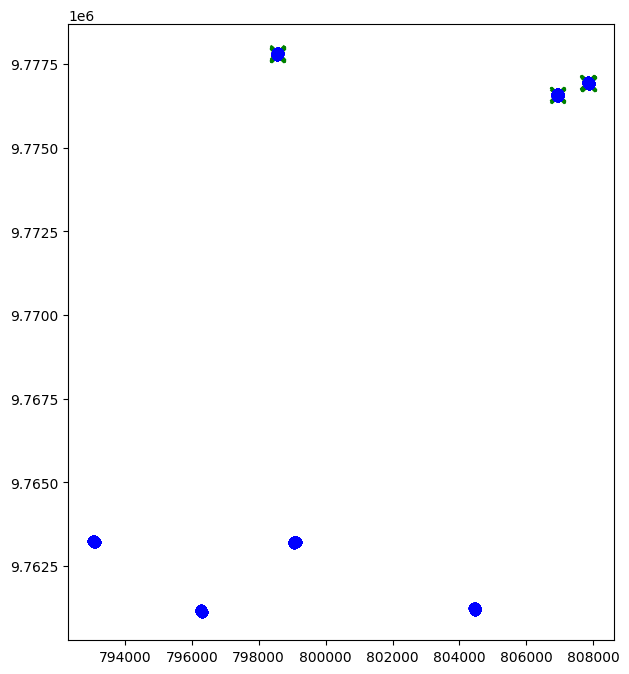

In [ ]:
fig, ax = plt.subplots(figsize = (10, 8))
gdf_acre_drone.set_geometry('geometry').plot(ax=ax, facecolor='none', edgecolor='green', linewidth=2, label='Drone Polygon')

#plot drone centroids
gdf_acre_drone.set_geometry('centroid').plot(ax=ax, color='green', marker='x', markersize=100, label='Drone Centroid')

#plot ground truth points
gdf_gt_ecoplanet.plot(ax=ax, color='blue', marker='o', markersize=50, label='Ground Truth Point')

##### Adding back a date of collection column to the dataset

In [2]:
final = '../02_INTERMEDIATE/final_merged_bamboo_production.gpkg'
final_gdf = gpd.read_file(final)

In [3]:
final_gdf.columns

Index(['ecoplanet_plot_id', 'ecoplanet_year', 'ecoplanet_clump_id',
       'ecoplanet_total_culms', 'ecoplanet_total_agb',
       'ecoplanet_max_culm_diameter_cm', 'ecoplanet_avg_culm_diameter_cm',
       'ecoplanet_min_culm_diameter_cm', 'ecoplanet_median_culm_diameter_cm',
       'ecoplanet_max_culm_agb', 'ecoplanet_avg_culm_agb',
       'ecoplanet_min_culm_agb', 'ecoplanet_median_culm_agb', 'ecoplanet_lat',
       'ecoplanet_lon', 'year', 'acre_drone_fid', 'acre_drone_hmin',
       'acre_drone_hmax', 'acre_drone_hmean', 'acre_drone_hstd',
       'acre_drone_hmedian', 'acre_drone_total_points',
       'acre_drone_canopy_volume_m3', 'acre_drone_gap_fraction',
       'acre_drone_canopy_area', 'acre_drone_layer', 'acre_drone_path',
       'drone_match_status', 'val_point_name', 'val_height',
       'val_canopy_diameter', 'validation_match_status', 'geometry'],
      dtype='str')

In [4]:
final_gdf.drop(columns=['year', 'acre_drone_fid', 'acre_drone_layer', 'acre_drone_path',
       'drone_match_status', 'val_point_name', 'validation_match_status'], inplace=True)

In [5]:
final_gdf.head()

,ecoplanet_plot_id,ecoplanet_year,ecoplanet_clump_id,ecoplanet_total_culms,ecoplanet_total_agb,ecoplanet_max_culm_diameter_cm,ecoplanet_avg_culm_diameter_cm,ecoplanet_min_culm_diameter_cm,ecoplanet_median_culm_diameter_cm,ecoplanet_max_culm_agb,...,acre_drone_hmean,acre_drone_hstd,acre_drone_hmedian,acre_drone_total_points,acre_drone_canopy_volume_m3,acre_drone_gap_fraction,acre_drone_canopy_area,val_height,val_canopy_diameter,geometry
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,...,4.686056509657434,0.9464393533744835,5.057555675506592,213539,148.1082314248925,0.0165824509808512,27.47487899950287,NaN,NaN,POINT (29.68377 -2.00779)
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,...,3.322943584735577,0.847565622108087,3.2455556392669678,42938,30.024417186252435,0.0355861940472308,7.799999999254944,NaN,NaN,POINT (29.6838 -2.00783)
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,...,2.723424044522372,0.42574329263063887,2.6875555515289307,54200,48.96567438569729,0.0581549815498155,14.079999999194397,NaN,NaN,POINT (29.6838 -2.00787)
3,1a-APM-01,2025,CLUMP #4,1,0.78,0.91,0.91,0.91,0.91,0.78,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (29.6838 -2.00793)
4,1a-APM-01,2025,CLUMP #5,0,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (29.68377 -2.00796)


In [7]:
final_gdf['ecoplanet_plot_id'].unique()

<StringArray>
['1a-APM-01', '1a-APM-02', '1a-APM-07', '1a-APM-08', '1a-APM-13',  '1a-GB-03',
  '1a-GB-05']
Length: 7, dtype: str

In [8]:
date_mapping = {
    ('1a-APM-01', 2025): "2025-04-24",
    ('1a-APM-01', 2026): "2026-04-02",
    ('1a-APM-02', 2025): "2025-04-25",
    ('1a-APM-02', 2026): "2026-05-03",
    ('1a-APM-07', 2025): "2025-05-15",
    ('1a-APM-07', 2026): "2026-02-20",
    ('1a-APM-08', 2025): "2025-05-15",
    ('1a-APM-08', 2026): "2026-02-24",
    ('1a-APM-13', 2025): "2025-06-18",
    ('1a-APM-13', 2026): "2026-03-17",
    ('1a-GB-03', 2025): "2025-05-20",
    ('1a-GB-03', 2026): "2026-06-03",
    ('1a-GB-05', 2025): "2025-06-18",
    ('1a-GB-05', 2026): "2026-03-13"
}

# 2. Create a temporary lookup key from the existing GDF columns
lookup_key = zip(final_gdf["ecoplanet_plot_id"], final_gdf["ecoplanet_year"])

# 3. Map the dates to a new column and convert to datetime format
final_gdf["date_of_collection"] = [date_mapping.get(key, None) for key in lookup_key]
final_gdf["date_of_collection"] = gpd.pd.to_datetime(final_gdf["date_of_collection"])

In [9]:
final_gdf.head()

,ecoplanet_plot_id,ecoplanet_year,ecoplanet_clump_id,ecoplanet_total_culms,ecoplanet_total_agb,ecoplanet_max_culm_diameter_cm,ecoplanet_avg_culm_diameter_cm,ecoplanet_min_culm_diameter_cm,ecoplanet_median_culm_diameter_cm,ecoplanet_max_culm_agb,...,acre_drone_hstd,acre_drone_hmedian,acre_drone_total_points,acre_drone_canopy_volume_m3,acre_drone_gap_fraction,acre_drone_canopy_area,val_height,val_canopy_diameter,geometry,date_of_collection
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,...,0.9464393533744835,5.057555675506592,213539,148.1082314248925,0.0165824509808512,27.47487899950287,NaN,NaN,POINT (29.68377 -2.00779),2025-04-24
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,...,0.847565622108087,3.2455556392669678,42938,30.024417186252435,0.0355861940472308,7.799999999254944,NaN,NaN,POINT (29.6838 -2.00783),2025-04-24
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.42574329263063887,2.6875555515289307,54200,48.96567438569729,0.0581549815498155,14.079999999194397,NaN,NaN,POINT (29.6838 -2.00787),2025-04-24
3,1a-APM-01,2025,CLUMP #4,1,0.78,0.91,0.91,0.91,0.91,0.78,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (29.6838 -2.00793),2025-04-24
4,1a-APM-01,2025,CLUMP #5,0,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (29.68377 -2.00796),2025-04-24


#### Adding the June 2026 dataset for Ecoplanet to the final geodataframe

In [15]:
psp_05_june_26 = '../01_RAW/1a-GB-5__June_24_2026.xlsx'
psp_05_june_26_df = pd.read_excel(psp_05_june_26)

In [16]:
to_be_cleaned = [psp_05_june_26_df]

In [17]:
def clean_biomass_df(df):
    """
    Cleans and structures biomass data from the provided excel sheet layout.
    Preserves clumps with no records by creating a single row placeholder 
    noting "No records found" instead of skipping them.
    """
    plot_id = None
    date_val = None
    
    # 1. Target exact cell coordinates for global Plot Metadata
    for r in range(min(3, df.shape[0])):
        row_values = [str(x).strip() for x in df.iloc[r].tolist()]
        for idx, val in enumerate(row_values):
            if '1a-' in val.lower() or 'apm' in val.lower():
                plot_id = val
            if 'DATE' in val.upper() and idx + 1 < len(row_values):
                date_val = row_values[idx + 1]

    # 2. Dynamically find all Clump start columns from Row index 2
    clump_indices = []
    if df.shape[0] > 2:
        row_2 = df.iloc[2].tolist()
        for idx, val in enumerate(row_2):
            if pd.notna(val) and 'CLUMP' in str(val).upper():
                clump_indices.append(idx)
                
    all_clumps = []
    num_cols = df.shape[1]
    
    # 3. Process each clump based on dynamic boundaries
    for i, start_col in enumerate(clump_indices):
        end_col = clump_indices[i + 1] if i + 1 < len(clump_indices) else num_cols
        
        # Slice the chunk for this specific clump
        clump_chunk = df.iloc[:, start_col:end_col]
        
        # Extract Clump ID
        clump_id = str(df.iloc[2, start_col]).strip()
        
        if df.shape[0] <= 5:
            continue
            
        # Extract data rows from row index 5 downward
        data_rows = clump_chunk.iloc[5:].copy()
        
        # Dynamic Column Naming using robust case-insensitive substring checks
        headers = [str(h).strip().upper() for h in clump_chunk.iloc[4].tolist()]
        col_names = []
        for idx, h in enumerate(headers):
            if 'NUMBER' in h:
                col_names.append('Culm_Number')
            elif 'DIAMETER (CM)' in h or 'DIAMETER_CM' in h:
                col_names.append('Culm_Diameter_cm')
            elif 'DIAMETER (MM)' in h or 'DIAMETER_MM' in h:
                col_names.append('Culm_Diameter_mm')
            elif 'AGB_CULM' in h or '(KG)' in h:
                col_names.append('AGB_Culm')
            else:
                col_names.append(f'Spacer_Col_{idx}')
                
        data_rows.columns = col_names
        
        # 4. Clean data rows and drop footer/totals
        # First, drop completely empty records in Culm_Number
        data_rows = data_rows.dropna(subset=['Culm_Number'])
        
        # Safe string evaluation to eliminate rows matching summary labels like 'AGB CLUMP'
        def is_summary_row(row):
            for val in row.values:
                if pd.notna(val) and 'AGB CLUMP' in str(val).upper():
                    return True
            return False
            
        summary_mask = data_rows.apply(is_summary_row, axis=1)
        data_rows = data_rows[~summary_mask]
        
        # Filter down to valid numeric indices to separate spacer values from numeric logs
        data_rows['Culm_Number_Numeric'] = pd.to_numeric(data_rows['Culm_Number'], errors='coerce')
        data_rows = data_rows.dropna(subset=['Culm_Number_Numeric']).drop(columns=['Culm_Number_Numeric'])
        
        # --- NEW LOGIC: Handle empty clumps gracefully ---
        if data_rows.empty:
            # Create a fallback single row dictionary filled with your preservation note
            fallback_row = {
                'Culm_Number': 'No records found',
                'Culm_Diameter_cm': 'No records found',
                'AGB_Culm': 'No records found'
            }
            # Fallback for mm tracking columns if present in sheet structures
            if 'Culm_Diameter_mm' in col_names:
                fallback_row['Culm_Diameter_mm'] = 'No records found'
                
            data_rows = pd.DataFrame([fallback_row])
        else:
            # Remove unwanted spacer columns dynamically if the data rows exist
            data_rows = data_rows.loc[:, ~data_rows.columns.str.startswith('Spacer_Col_')]
        
        # Inject metadata
        data_rows['Plot_ID'] = plot_id
        data_rows['Date'] = date_val
        data_rows['Clump_ID'] = clump_id
        
        all_clumps.append(data_rows)
        
    # 5. Concatenate all data chunks safely
    cols_order = ['Plot_ID', 'Date', 'Clump_ID', 'Culm_Number', 'Culm_Diameter_cm', 'AGB_Culm']
    
    if not all_clumps:
        return pd.DataFrame(columns=cols_order)
        
    cleaned_df = pd.concat(all_clumps, ignore_index=True)
    
    # Ensure all columns exist in final output schema even if empty
    for c in cols_order:
        if c not in cleaned_df.columns:
            cleaned_df[c] = None
            
    return cleaned_df[cols_order]


In [18]:
master_list = []

for raw_df in to_be_cleaned:
    # Clean each already-loaded df using the function
    cleaned_data = clean_biomass_df(raw_df)
    
    # FIX 1: Only append if the dataframeA actually contains extracted rows
    if not cleaned_data.empty:
        master_list.append(cleaned_data)

# FIX 2: Prevent pd.concat crash if no valid data was found across all sheets
if master_list:
    final_dataset = pd.concat(master_list, ignore_index=True)
    
    # FIX 3: Safe datetime conversion with errors='coerce' to bypass messy strings
    final_dataset['Date'] = pd.to_datetime(final_dataset["Date"], errors='coerce', format="mixed")
    
    # Extract only the date component safely, ignoring nulls
    final_dataset['Year'] = final_dataset['Date'].dt.year
    final_dataset['Date'] = final_dataset["Date"].dt.date
else:
    # Fallback to an empty dataframe with correct schema if no data matched
    cols_order = ['Plot_ID', 'Date', 'Clump_ID', 'Culm_Number', 'Culm_Diameter_cm', 'AGB_Culm']
    final_dataset = pd.DataFrame(columns=cols_order)

In [19]:
final_dataset.head()

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
0,1a-GB-05,2026-06-24,CLUMP #1,1,0,0,2026
1,1a-GB-05,2026-06-24,CLUMP #1,2,0,0,2026
2,1a-GB-05,2026-06-24,CLUMP #1,3,0,0,2026
3,1a-GB-05,2026-06-24,CLUMP #1,4,0,0,2026
4,1a-GB-05,2026-06-24,CLUMP #1,5,0,0,2026


In [20]:
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Plot_ID           950 non-null    str   
 1   Date              950 non-null    object
 2   Clump_ID          950 non-null    str   
 3   Culm_Number       950 non-null    object
 4   Culm_Diameter_cm  949 non-null    object
 5   AGB_Culm          950 non-null    object
 6   Year              950 non-null    int32 
dtypes: int32(1), object(4), str(2)
memory usage: 48.4+ KB


In [21]:
def clean_bamboo_2025_zeros(df):
    # 1. Subset the records for the year 2025
    df_2025 = df[df['Year'] == 2026].copy()
    
    # 2. Separate rows with real culms (> 0 diameter) from zero entries
    valid_culms = df_2025[df_2025['Culm_Diameter_cm'] > 0].copy()
    zero_culms = df_2025[df_2025['Culm_Diameter_cm'] == 0].copy()
    
    # 3. Handle clumps where every single record is 0
    # Find unique Plot+Clump combinations that have at least one valid culm
    valid_clump_keys = valid_culms[['Plot_ID', 'Clump_ID']].drop_duplicates()
    
    # Left join zero records with valid keys to flag clumps that have valid culms
    merged = zero_culms.merge(valid_clump_keys, on=['Plot_ID', 'Clump_ID'], how='left', indicator=True)
    
    # Filter for rows where the Plot+Clump combination has NO valid culms at all
    all_zero_clumps = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
    
    # Drop duplicates to keep exactly one record per all-zero clump
    preserved_clumps = all_zero_clumps.drop_duplicates(subset=['Plot_ID', 'Clump_ID']).copy()
    
    # Force the Culm_Number to 0 for these completely empty clumps
    preserved_clumps['Culm_Number'] = 0
    
    # 4. Recombine valid culms and preserved empty clumps
    cleaned_df = pd.concat([valid_culms, preserved_clumps]).sort_index()
    
    # 5. Recalculate and update the Culm_Number to reflect the true non-zero count
    # Count how many valid culms exist per unique Plot + Clump combination
    true_counts = valid_culms.groupby(['Plot_ID', 'Clump_ID']).size().reset_index(name='True_Count')
    
    # Map the true counts back to the cleaned dataframe
    cleaned_df = cleaned_df.merge(true_counts, on=['Plot_ID', 'Clump_ID'], how='left')
    cleaned_df['Culm_Number'] = cleaned_df['True_Count'].fillna(0).astype(int)
    cleaned_df = cleaned_df.drop(columns=['True_Count'])
    
    return cleaned_df


In [22]:
final_no_zeros = clean_bamboo_2025_zeros(final_dataset)

In [23]:
final_no_zeros.head()

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
0,1a-GB-05,2026-06-24,CLUMP #1,0,0,0,2026
1,1a-GB-05,2026-06-24,CLUMP #2,49,3.537,9.099812,2026
2,1a-GB-05,2026-06-24,CLUMP #2,49,2.927,6.469335,2026
3,1a-GB-05,2026-06-24,CLUMP #2,49,2.977,6.669875,2026
4,1a-GB-05,2026-06-24,CLUMP #2,49,3.017,6.832267,2026


In [24]:
final_no_zeros.info()

<class 'pandas.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Plot_ID           589 non-null    str   
 1   Date              589 non-null    object
 2   Clump_ID          589 non-null    str   
 3   Culm_Number       589 non-null    int64 
 4   Culm_Diameter_cm  589 non-null    object
 5   AGB_Culm          589 non-null    object
 6   Year              589 non-null    int32 
dtypes: int32(1), int64(1), object(3), str(2)
memory usage: 30.0+ KB


In [25]:
final_no_zeros.sample(10)

,Plot_ID,Date,Clump_ID,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
406,1a-GB-05,2026-06-24,CLUMP #11,82,1.789,2.663801,2026
283,1a-GB-05,2026-06-24,CLUMP #8,49,2.819,6.045498,2026
141,1a-GB-05,2026-06-24,CLUMP #5,48,3.329,8.158177,2026
168,1a-GB-05,2026-06-24,CLUMP #5,48,3.737,10.048154,2026
334,1a-GB-05,2026-06-24,CLUMP #9,32,2.091,3.528559,2026
158,1a-GB-05,2026-06-24,CLUMP #5,48,3.297,8.017384,2026
275,1a-GB-05,2026-06-24,CLUMP #8,49,2.871,6.247972,2026
99,1a-GB-05,2026-06-24,CLUMP #4,50,3.437,8.64139,2026
587,1a-GB-05,2026-06-24,CLUMP #15,38,2.529,4.97118,2026
433,1a-GB-05,2026-06-24,CLUMP #11,82,1.951,3.11425,2026


In [30]:
final_no_zeros = final_no_zeros.astype({'Culm_Diameter_cm': float, 'AGB_Culm':float})

In [31]:
final_no_zeros.isna().sum()

Plot_ID             0
Date                0
Clump_ID            0
Culm_Number         0
Culm_Diameter_cm    0
AGB_Culm            0
Year                0
dtype: int64

In [32]:
final_no_zeros.describe()

,Culm_Number,Culm_Diameter_cm,AGB_Culm,Year
count,589.000000,589.000000,589.000000,589.0
mean,49.477080,2.518416,5.328979,2026.0
std,16.307574,0.837276,3.020128,0.0
min,0.000000,0.000000,0.000000,2026.0
25%,38.000000,1.889000,2.938160,2026.0
50%,48.000000,2.545000,5.028008,2026.0
75%,50.000000,3.080000,7.091553,2026.0
max,82.000000,5.153000,17.929840,2026.0


In [33]:
final_no_zeros.columns = final_no_zeros.columns.str.lower()

In [35]:
final_no_zeros.columns

Index(['plot_id', 'date', 'clump_id', 'culm_number', 'culm_diameter_cm',
       'agb_culm', 'year'],
      dtype='str')

In [36]:
# Strip whitespace and pad the final number with a leading zero if it is a single digit
final_no_zeros['plot_id'] = final_no_zeros['plot_id'].astype(str).str.replace(
    r'-(\d+)$', 
    lambda x: f"-{int(x.group(1)):02d}", 
    regex=True
)

In [37]:
final_no_zeros['plot_id'].unique()

<StringArray>
['1a-GB-05']
Length: 1, dtype: str

#### Is the dataframe complete

In [38]:
# 1. Get all unique plots and years actually present in your data
unique_plots = final_no_zeros['plot_id'].unique()
unique_years = final_no_zeros['year'].unique()

# 2. Generate the 15 expected clump IDs
expected_clumps = [f"CLUMP #{i}" for i in range(1, 16)]

# 3. Build a perfect reference grid of all required combinations
expected_grid = pd.MultiIndex.from_product(
    [unique_plots, unique_years, expected_clumps],
    names=['plot_id', 'year', 'clump_id']
)

In [40]:
# 4. Convert your current data's columns into a MultiIndex
actual_grid = pd.MultiIndex.from_frame(final_no_zeros[['plot_id', 'year', 'clump_id']])

# 5. Find the combinations that exist in the expected grid but not in your data
missing_combinations = expected_grid.difference(actual_grid)

# 6. Convert the result into a readable DataFrame
missing_df = missing_combinations.to_frame(index=False)

In [41]:
missing_df

,plot_id,year,clump_id


#### Aggregating the biomass values for 2026

In [42]:
final_no_zeros['agb_culm'] = final_no_zeros['agb_culm'].round(2)
final_no_zeros['culm_diameter_cm'] = final_no_zeros['culm_diameter_cm'].round(2)

In [98]:
df_clean = final_no_zeros.copy()

# --- STEP 1.5: Temporarily turn 0s to NaN for biomass calculations ---
# This ensures 0s don't skew min, mean, or median downward.
df_clean["agb_culm_nan"] = df_clean["agb_culm"].replace(0, np.nan)

# --- STEP 2: Aggregate the Data ---
aggregated_df = (
    df_clean.groupby(["plot_id", "date", "year", "clump_id"])
    .agg(
        # Calculate stats using the column where 0s are NaN (they will be ignored)
        max_culm_agb=("agb_culm_nan", "max"),
        max_culm_diameter_cm=("culm_diameter_cm", "max"),
        avg_culm_diameter_cm=("culm_diameter_cm", "mean"),
        median_culm_diameter_cm=("culm_diameter_cm", "median"),
        min_culm_diameter_cm=("culm_diameter_cm", "min"),
        avg_culm_agb=("agb_culm_nan", "mean"),
        min_culm_agb=("agb_culm_nan", "min"),
        median_culm_agb=("agb_culm_nan", "median"),
        total_agb=("agb_culm_nan", "sum"),
        # Culm count still looks at the original column to capture everything
        total_culms=("culm_number", "max"),
    )
    .reset_index()
)

# --- STEP 3: Handle completely empty clumps ---
# If a clump only had 0s, its stats are NaN. Turn them back to 0.0.
cols_to_zero = [
    "max_culm_agb",
    "avg_culm_agb",
    "min_culm_agb",
    "median_culm_agb",
    "total_agb"
]
aggregated_df[cols_to_zero] = aggregated_df[cols_to_zero].fillna(
    0.0
)

In [99]:
aggregated_df.head()

,plot_id,date,year,clump_id,max_culm_agb,max_culm_diameter_cm,avg_culm_diameter_cm,median_culm_diameter_cm,min_culm_diameter_cm,avg_culm_agb,min_culm_agb,median_culm_agb,total_agb,total_culms
0,1a-GB-05,2026-06-24,2026,CLUMP #1,0.00,0.00,0.000000,0.00,0.00,0.000000,0.00,0.00,0.00,0
1,1a-GB-05,2026-06-24,2026,CLUMP #10,8.88,3.49,2.357805,2.40,1.16,4.508780,1.22,4.54,184.86,41
2,1a-GB-05,2026-06-24,2026,CLUMP #11,10.66,3.86,2.217439,2.27,0.56,4.295244,0.33,4.09,352.21,82
3,1a-GB-05,2026-06-24,2026,CLUMP #12,17.93,5.15,2.785957,2.86,1.03,6.321702,0.99,6.19,297.12,47
4,1a-GB-05,2026-06-24,2026,CLUMP #13,6.63,2.97,2.333636,2.52,1.23,4.469091,1.36,4.93,49.16,11


In [100]:
aggregated_df.to_csv('../02_INTERMEDIATE/psp_05_june_26.csv', index=False)

#### Final geodataframe joining to the psp 05 

In [101]:
final_gdf.head()

,plot_id,year,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,...,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,val_height,val_canopy_diameter,geometry,date_of_collection
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,...,0.9464393533744835,5.057555675506592,213539,148.1082314248925,0.0165824509808512,27.47487899950287,NaN,NaN,POINT (29.68377 -2.00779),2025-04-24
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,...,0.847565622108087,3.2455556392669678,42938,30.024417186252435,0.0355861940472308,7.799999999254944,NaN,NaN,POINT (29.6838 -2.00783),2025-04-24
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.42574329263063887,2.6875555515289307,54200,48.96567438569729,0.0581549815498155,14.079999999194397,NaN,NaN,POINT (29.6838 -2.00787),2025-04-24
3,1a-APM-01,2025,CLUMP #4,1,0.78,0.91,0.91,0.91,0.91,0.78,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (29.6838 -2.00793),2025-04-24
4,1a-APM-01,2025,CLUMP #5,0,0.00,0.00,0.00,0.00,0.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (29.68377 -2.00796),2025-04-24


In [102]:
final_gdf.columns

Index(['plot_id', 'year', 'clump_id', 'total_culms', 'total_agb',
       'max_culm_diameter_cm', 'avg_culm_diameter_cm', 'min_culm_diameter_cm',
       'median_culm_diameter_cm', 'max_culm_agb', 'avg_culm_agb',
       'min_culm_agb', 'median_culm_agb', 'lat', 'lon', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry', 'date_of_collection'],
      dtype='str')

In [ ]:
prefixes_to_drop = ['ecoplanet_', 'acre_']

In [55]:
drone_prefix = ['drone_']

In [53]:
final_gdf.columns = [
    next((col.removeprefix(p) for p in prefixes_to_drop if col.startswith(p)), col)
    for col in final_gdf.columns
]

In [56]:
final_gdf.columns = [
    next((col.removeprefix(p) for p in drone_prefix if col.startswith(p)), col)
    for col in final_gdf.columns
]

In [103]:
final_gdf.columns

Index(['plot_id', 'year', 'clump_id', 'total_culms', 'total_agb',
       'max_culm_diameter_cm', 'avg_culm_diameter_cm', 'min_culm_diameter_cm',
       'median_culm_diameter_cm', 'max_culm_agb', 'avg_culm_agb',
       'min_culm_agb', 'median_culm_agb', 'lat', 'lon', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry', 'date_of_collection'],
      dtype='str')

In [104]:
aggregated_df.columns

Index(['plot_id', 'date', 'year', 'clump_id', 'max_culm_agb',
       'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'median_culm_diameter_cm', 'min_culm_diameter_cm', 'avg_culm_agb',
       'min_culm_agb', 'median_culm_agb', 'total_agb', 'total_culms'],
      dtype='str')

In [105]:
aggregated_df.rename(columns={'date':'date_of_collection'}, inplace=True)

In [106]:
aggregated_df['date_of_collection'] = pd.to_datetime(aggregated_df['date_of_collection'])

In [107]:
aggregated_df.dtypes

plot_id                              str
date_of_collection         datetime64[s]
year                               int32
clump_id                             str
max_culm_agb                     float64
max_culm_diameter_cm             float64
avg_culm_diameter_cm             float64
median_culm_diameter_cm          float64
min_culm_diameter_cm             float64
avg_culm_agb                     float64
min_culm_agb                     float64
median_culm_agb                  float64
total_agb                        float64
total_culms                        int64
dtype: object

In [108]:
final_gdf.dtypes

plot_id                               str
year                                int64
clump_id                              str
total_culms                         int64
total_agb                         float64
max_culm_diameter_cm              float64
avg_culm_diameter_cm              float64
min_culm_diameter_cm              float64
median_culm_diameter_cm           float64
max_culm_agb                      float64
avg_culm_agb                      float64
min_culm_agb                      float64
median_culm_agb                   float64
lat                               float64
lon                               float64
hmin                                  str
hmax                                  str
hmean                                 str
hstd                                  str
hmedian                               str
total_points                          str
canopy_volume_m3                      str
gap_fraction                          str
canopy_area                       

In [109]:
combined_gdf = pd.concat([final_gdf, aggregated_df], ignore_index=True)

In [110]:
combined_gdf.sample(6)

,plot_id,year,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,...,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,val_height,val_canopy_diameter,geometry,date_of_collection
98,1a-APM-08,2025,CLUMP #9,0,0.00,0.00,0.000000,0.00,0.00,0.00,...,0.13074278165139547,2.1848888397216797,13581,5.46537771606913,0.2895957587806494,2.0399999994924287,NaN,NaN,POINT (29.759 -2.0191),2025-05-15
40,1a-APM-02,2025,CLUMP #11,18,28.71,2.37,1.230000,0.49,1.17,4.43,...,0.5624406789704984,3.601555585861206,123812,127.81305474868208,0.2643200982134203,26.440000003171154,NaN,NaN,POINT (29.73694 -2.15768),2025-04-25
167,1a-GB-03,2026,CLUMP #13,0,0.00,0.00,0.000000,0.00,0.00,0.00,...,0.11473616295927691,2.1114444732666016,9255,3.0682007205319017,0.4063749324689357,1.4104759303042036,NaN,NaN,POINT (29.66367 -2.15883),2026-06-03
211,1a-GB-05,2026,CLUMP #10,41,184.86,3.49,2.357805,1.16,2.40,8.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-06-24
28,1a-APM-01,2026,CLUMP #14,11,11.42,1.69,1.000000,0.33,0.97,2.41,...,0.4350025644533586,2.8337221145629883,39590,22.544747480959117,0.2870169234655216,7.199999999720604,NaN,NaN,POINT (29.68364 -2.00832),2026-04-02
5,1a-APM-01,2025,CLUMP #6,0,0.00,0.00,0.000000,0.00,0.00,0.00,...,0.42765355280673795,2.7610554695129395,16513,11.184131689272162,0.2650638890571065,3.6800000008242213,NaN,NaN,POINT (29.68374 -2.008),2025-04-24


In [111]:
len(combined_gdf)

225

In [112]:
combined_gdf.dtypes

plot_id                               str
year                                int64
clump_id                              str
total_culms                         int64
total_agb                         float64
max_culm_diameter_cm              float64
avg_culm_diameter_cm              float64
min_culm_diameter_cm              float64
median_culm_diameter_cm           float64
max_culm_agb                      float64
avg_culm_agb                      float64
min_culm_agb                      float64
median_culm_agb                   float64
lat                               float64
lon                               float64
hmin                                  str
hmax                                  str
hmean                                 str
hstd                                  str
hmedian                               str
total_points                          str
canopy_volume_m3                      str
gap_fraction                          str
canopy_area                       

In [113]:
combined_gdf = combined_gdf.astype({'hmin':float, 'hmax': float, 'hmean':float, 'hstd':float, 'hmedian':float, 'total_points':float, 'canopy_volume_m3':float, 'gap_fraction':float, 'canopy_area': float, 'val_height':float,
                                    'val_canopy_diameter':float})

In [114]:
combined_gdf["clump_num"] = (
    combined_gdf["clump_id"].str.extract(r"(\d+)").astype(int)
)

# Sort using the temporary numeric columns, but keep dates chronological
combined_gdf = combined_gdf.sort_values(by=["plot_id", "clump_num", "date_of_collection"])

# Drop the temporary sorting columns when done
combined_gdf = combined_gdf.drop(columns=["clump_num"])

In [115]:
combined_gdf.head()

,plot_id,year,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,...,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,val_height,val_canopy_diameter,geometry,date_of_collection
0,1a-APM-01,2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,5.89,...,0.946439,5.057556,213539.0,148.108231,0.016582,27.474879,NaN,NaN,POINT (29.68377 -2.00779),2025-04-24
15,1a-APM-01,2026,CLUMP #1,31,144.28,3.59,2.35,0.66,2.45,9.36,...,1.350432,5.293056,226341.0,287.124916,0.041733,46.720000,NaN,NaN,POINT (29.68374 -2.00775),2026-04-02
1,1a-APM-01,2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,3.73,...,0.847566,3.245556,42938.0,30.024417,0.035586,7.800000,NaN,NaN,POINT (29.6838 -2.00783),2025-04-24
16,1a-APM-01,2026,CLUMP #2,58,172.09,3.03,1.81,0.23,1.81,6.89,...,0.946439,5.057556,213539.0,148.108231,0.016582,27.474879,NaN,NaN,POINT (29.68377 -2.00779),2026-04-02
2,1a-APM-01,2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.425743,2.687556,54200.0,48.965674,0.058155,14.080000,NaN,NaN,POINT (29.6838 -2.00787),2025-04-24


In [116]:
combined_gdf.isna().sum()

plot_id                      0
year                         0
clump_id                     0
total_culms                  0
total_agb                    0
max_culm_diameter_cm         0
avg_culm_diameter_cm         0
min_culm_diameter_cm         0
median_culm_diameter_cm      0
max_culm_agb                 0
avg_culm_agb                 0
min_culm_agb                 0
median_culm_agb              0
lat                         15
lon                         15
hmin                        63
hmax                        63
hmean                       63
hstd                        63
hmedian                     63
total_points                63
canopy_volume_m3            63
gap_fraction                63
canopy_area                 63
val_height                 185
val_canopy_diameter        197
geometry                    15
date_of_collection           0
dtype: int64

In [94]:
combined_gdf.columns

Index(['plot_id', 'year', 'clump_id', 'total_culms', 'total_agb',
       'max_culm_diameter_cm', 'avg_culm_diameter_cm', 'min_culm_diameter_cm',
       'median_culm_diameter_cm', 'max_culm_agb', 'avg_culm_agb',
       'min_culm_agb', 'median_culm_agb', 'lat', 'lon', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry', 'date_of_collection'],
      dtype='str')

In [121]:
combined_gdf.drop(columns=['lat', 'lon'], inplace=True)

In [123]:
combined_gdf = combined_gdf[['plot_id', 'year', 'date_of_collection', 'clump_id', 'total_culms', 'total_agb',
       'max_culm_diameter_cm', 'avg_culm_diameter_cm', 'min_culm_diameter_cm',
       'median_culm_diameter_cm', 'max_culm_agb', 'avg_culm_agb',
       'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry']]

In [ ]:
# combined_gdf.to_csv('../02_INTERMEDIATE/combined_csv.csv', index=False)

In [135]:
combined_clean = pd.read_csv('../02_INTERMEDIATE/combined_csv.csv')

In [136]:
combined_clean.head()

,plot_id,year,date_of_collection,clump_id,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,...,hmean,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,val_height,val_canopy_diameter,geometry
0,1a-APM-01,2025,4/24/2025,CLUMP #1,11,34.65,2.78,1.86,0.36,1.85,...,4.686057,0.946439,5.057556,213539.0,148.108231,0.016582,27.474879,NaN,NaN,POINT (29.683770297603274 -2.0077856527395452)
1,1a-APM-01,2026,4/2/2026,CLUMP #1,31,144.28,3.59,2.35,0.66,2.45,...,4.931005,1.350432,5.293056,226341.0,287.124916,0.041733,46.720000,NaN,NaN,POINT (29.68374448598979 -2.007745734497771)
2,1a-APM-01,2025,4/24/2025,CLUMP #2,14,16.47,2.16,1.06,0.39,0.93,...,3.322944,0.847566,3.245556,42938.0,30.024417,0.035586,7.800000,NaN,NaN,POINT (29.683796242457305 -2.0078294280493507)
3,1a-APM-01,2026,4/2/2026,CLUMP #2,58,172.09,3.03,1.81,0.23,1.81,...,4.686057,0.946439,5.057556,213539.0,148.108231,0.016582,27.474879,NaN,NaN,POINT (29.68377008305298 -2.007785654471395)
4,1a-APM-01,2025,4/24/2025,CLUMP #3,0,0.00,0.00,0.00,0.00,0.00,...,2.723424,0.425743,2.687556,54200.0,48.965674,0.058155,14.080000,NaN,NaN,POINT (29.683804363397755 -2.0078747705928417)


In [137]:
combined_clean.columns

Index(['plot_id', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry'],
      dtype='str')

In [138]:
combined_clean.dtypes

plot_id                        str
year                         int64
date_of_collection             str
clump_id                       str
total_culms                  int64
total_agb                  float64
max_culm_diameter_cm       float64
avg_culm_diameter_cm       float64
min_culm_diameter_cm       float64
median_culm_diameter_cm    float64
max_culm_agb               float64
avg_culm_agb               float64
min_culm_agb               float64
median_culm_agb            float64
hmin                       float64
hmax                       float64
hmean                      float64
hstd                       float64
hmedian                    float64
total_points               float64
canopy_volume_m3           float64
gap_fraction               float64
canopy_area                float64
val_height                 float64
val_canopy_diameter        float64
geometry                       str
dtype: object

In [139]:
# 1. Find all float column names
float_cols = combined_clean.select_dtypes(include=['float']).columns

# 2. Round only those columns to 2 decimal places
combined_clean[float_cols] = combined_clean[float_cols].round(2)

In [140]:
combined_clean.describe()

,year,total_culms,total_agb,max_culm_diameter_cm,avg_culm_diameter_cm,min_culm_diameter_cm,median_culm_diameter_cm,max_culm_agb,avg_culm_agb,min_culm_agb,...,hmax,hmean,hstd,hmedian,total_points,canopy_volume_m3,gap_fraction,canopy_area,val_height,val_canopy_diameter
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,...,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,54.000000,42.000000
mean,2025.533333,22.320000,81.533822,2.201822,1.316533,0.482533,1.303600,5.323378,2.272800,0.360844,...,5.735795,4.166023,0.833807,4.299034,175958.136364,149.038466,0.249886,25.745852,5.762963,5.700000
std,0.500000,21.198147,100.349163,1.571936,0.909020,0.384082,0.927828,5.486913,2.025274,0.438828,...,1.671362,1.105944,0.362540,1.229387,124547.029827,106.035749,0.098480,14.787987,1.731429,1.243716
min,2025.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.310000,2.060000,0.110000,2.100000,8580.000000,3.070000,0.020000,1.410000,2.000000,3.000000
25%,2025.000000,3.000000,1.310000,0.720000,0.470000,0.240000,0.410000,0.510000,0.260000,0.070000,...,4.250000,3.230000,0.480000,3.250000,76343.250000,55.130000,0.190000,13.867500,4.900000,4.600000
50%,2026.000000,16.000000,35.720000,2.530000,1.540000,0.410000,1.480000,4.960000,2.160000,0.190000,...,5.970000,4.310000,0.875000,4.370000,158104.000000,139.490000,0.270000,26.065000,5.800000,5.950000
75%,2026.000000,38.000000,141.690000,3.380000,2.020000,0.700000,2.020000,8.390000,3.530000,0.500000,...,7.022500,4.935000,1.110000,5.185000,249802.000000,219.922500,0.320000,38.080000,6.200000,6.700000
max,2026.000000,82.000000,382.050000,9.040000,3.190000,1.650000,3.330000,49.410000,8.660000,2.200000,...,8.990000,6.500000,1.910000,7.170000,543933.000000,398.230000,0.410000,63.280000,9.100000,7.400000


In [143]:
from shapely import wkt
combined_clean['geometry'] = combined_clean['geometry'].apply(wkt.loads)

In [150]:
combined_clean_gdf = gpd.GeoDataFrame(combined_clean,
                                      geometry='geometry',
                                      crs="EPSG:32735")

In [151]:
combined_clean_gdf.columns

Index(['plot_id', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'geometry'],
      dtype='str')

In [152]:
combined_clean_gdf.rename(columns={'plot_id':'psp_id'}, inplace=True)

In [153]:
combined_clean_gdf.to_file('../02_INTERMEDIATE/final_bamboo_parameters.gpkg', index=False)

In [154]:
combined_clean_gdf.to_csv('../02_INTERMEDIATE/final_bamboo_parameters.csv', index=False)

In [157]:
combined_clean_gdf[combined_clean_gdf['year'] == 2026].isna().sum()

psp_id                      0
year                        0
date_of_collection          0
clump_id                    0
total_culms                 0
total_agb                   0
max_culm_diameter_cm        0
avg_culm_diameter_cm        0
min_culm_diameter_cm        0
median_culm_diameter_cm     0
max_culm_agb                0
avg_culm_agb                0
min_culm_agb                0
median_culm_agb             0
hmin                       25
hmax                       25
hmean                      25
hstd                       25
hmedian                    25
total_points               25
canopy_volume_m3           25
gap_fraction               25
canopy_area                25
val_height                 86
val_canopy_diameter        92
geometry                    0
dtype: int64